# AI Financial Data Analysis

### Import the required libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Load the dataset

In [3]:
df = pd.read_csv(r"H:\Downloads\ai_financial_market_daily_realistic_synthetic.csv")
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


### Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [5]:
df.describe()

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
count,10959.000000,10959.000000,10959.000000,10959.000000
mean,65.184504,44.126571,159.395988,0.025560
std,47.918247,41.639356,135.462185,0.749513
min,1.570000,-0.550000,-155.430000,-3.000000
25%,8.640000,3.610000,43.870000,-0.500000
50%,70.960000,35.220000,133.750000,0.000000
75%,99.600000,71.680000,258.300000,0.510000
max,163.830000,155.960000,565.500000,18.500000


## Data Cleaning 

### Convert the data type for the Date Column

In [8]:
print("Before: ")
print(df['Date'].dtype)

Before: 
object


In [10]:
print("Fixed! After: ")
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].dtype)

Fixed! After: 
datetime64[ns]


### Extracting Year and Month from the date column

##### Year

In [11]:
df['Year'] = df['Date'].dt.year

##### Month

In [12]:
df['Month'] = df['Date'].dt.month

In [13]:
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1
...,...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024,12
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024,12
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024,12
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024,12


## EDA

#### Number of unique Companies in our dataset

In [16]:
df['Company'].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

#### Research and Development Investment

###### Total capital allocated to Research and Development by each organization.

In [30]:
print("Company's spening for R & D IN $Bn: ")
RD = df.groupby('Company')['R&D_Spending_USD_Mn'].sum()
RD

Company's spening for R & D IN $Bn: 


Company
Google    423341.14
Meta      264533.07
OpenAI     26482.77
Name: R&D_Spending_USD_Mn, dtype: float64

###### A bar plot to show the amount spent on R & D by the companies

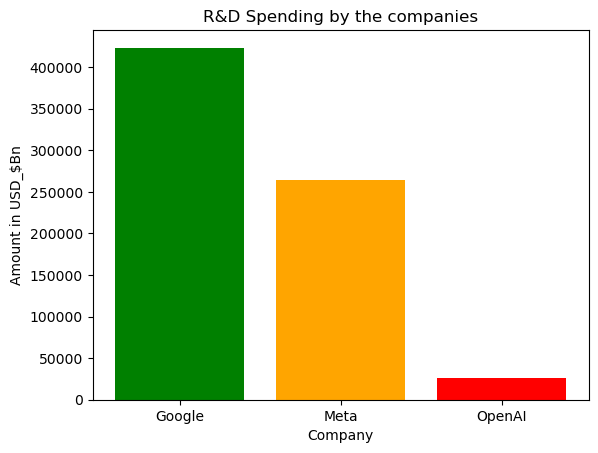

In [31]:
plt.bar(RD.index, RD.values, color = ['green', 'orange', 'red'])

plt.title( "R&D Spending by the companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD_$Bn")

plt.show()

#### Corporate Revenue Generation

###### Total earnings generated by the respective companies

In [34]:
print("Company's AI Revenue_USD_$Bn: ")

rev = df.groupby('Company')['AI_Revenue_USD_Mn'].sum()

rev

Company's AI Revenue_USD_$Bn: 


Company
Google    284498.38
Meta      189621.82
OpenAI      9462.89
Name: AI_Revenue_USD_Mn, dtype: float64

###### A bar plot to show the Revenues of each company

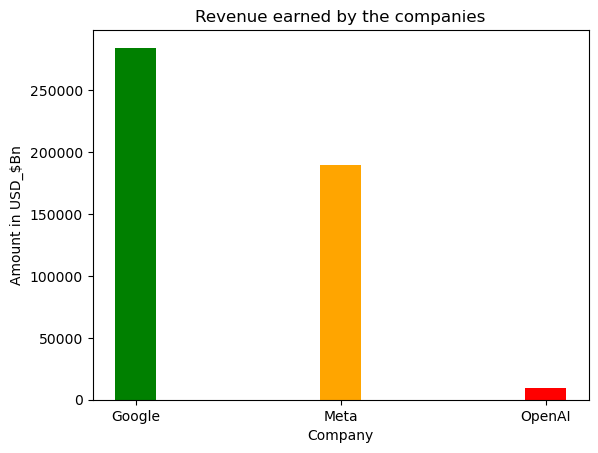

In [35]:
plt.bar(rev.index, rev.values, color = ['green', 'orange', 'red'], width = 0.2)

plt.title( "Revenue earned by the companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD_$Bn")

plt.show()

###### Bar plots to show expenditure & revenue of the companies

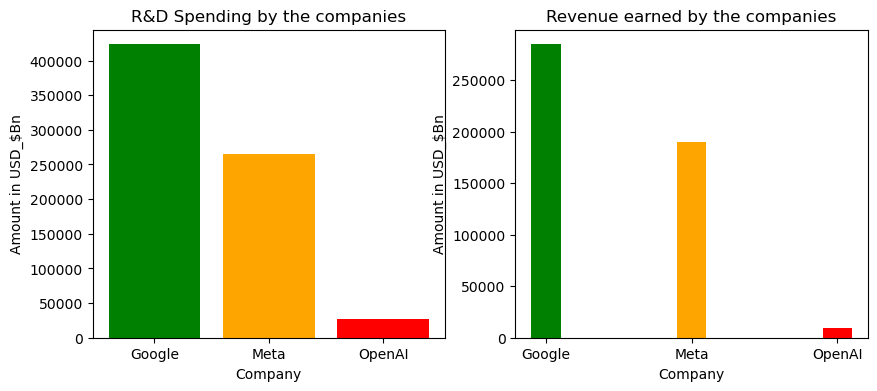

In [36]:


plt.figure(figsize = (10,4))

plt.subplot(1,2,1)

plt.bar(RD.index, RD.values, color = ['green', 'orange', 'red'])

plt.title( "R&D Spending by the companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD_$Bn")

plt.subplot(1,2,2)

plt.bar(rev.index, rev.values, color = ['green', 'orange', 'red'], width = 0.2)

plt.title( "Revenue earned by the companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD_$Bn")

plt.show()

#### Corporate Revenue Generation

###### The daily fluctuations and trends in stock market value over time

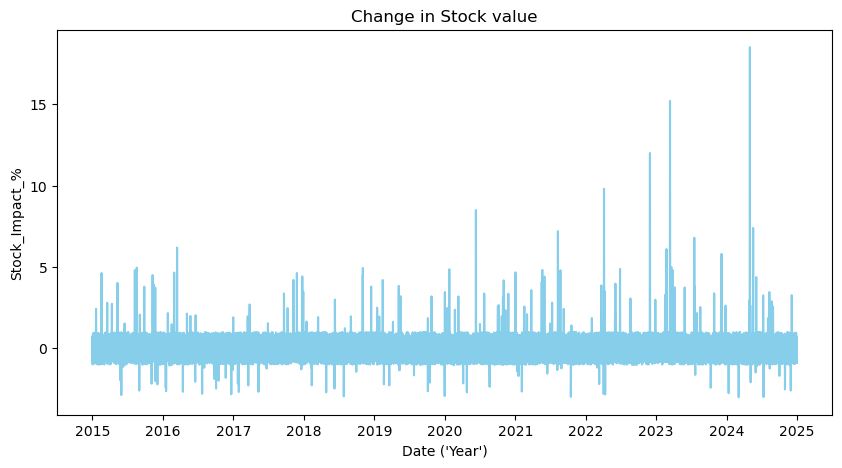

In [40]:
plt.figure(figsize = (10,5))

plt.plot(df['Date'], df['Stock_Impact_%'], color = 'skyblue')

plt.title("Change in Stock value")
plt.xlabel("Date ('Year')")
plt.ylabel("Stock_Impact_%")

plt.show()

### Daily Stock Performance

##### The daily fluctuations and trends in stock market value over time

###### Create 3 separate dataframes

In [41]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1


In [43]:
data_openAI = df [df['Company'] == 'OpenAI']
data_openAI

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1
...,...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93,2024,12
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25,2024,12
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47,2024,12
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69,2024,12


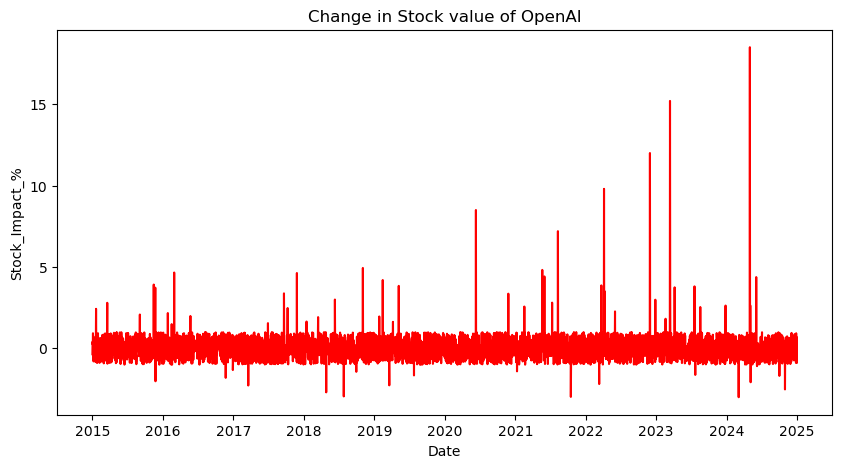

In [49]:
plt.figure(figsize = (10,5))

plt.plot(data_openAI['Date'], data_openAI['Stock_Impact_%'], color = 'red')

plt.title("Change in Stock value of OpenAI")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")

plt.show()

In [47]:
data_google = df [df['Company'] == 'Google']
data_google


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
3653,2015-01-01,Google,79.89,30.19,0.64,NaN,-0.02,2015,1
3654,2015-01-02,Google,78.99,30.44,1.47,NaN,-0.98,2015,1
3655,2015-01-03,Google,79.20,30.46,1.53,NaN,0.78,2015,1
3656,2015-01-04,Google,79.59,30.55,1.82,NaN,-0.41,2015,1
3657,2015-01-05,Google,81.50,30.59,1.97,NaN,-0.78,2015,1
...,...,...,...,...,...,...,...,...,...
7301,2024-12-27,Google,162.16,155.36,417.88,NaN,-0.46,2024,12
7302,2024-12-28,Google,159.69,154.47,414.89,NaN,-0.48,2024,12
7303,2024-12-29,Google,161.69,154.59,415.31,NaN,0.72,2024,12
7304,2024-12-30,Google,158.48,155.05,416.84,NaN,-0.17,2024,12


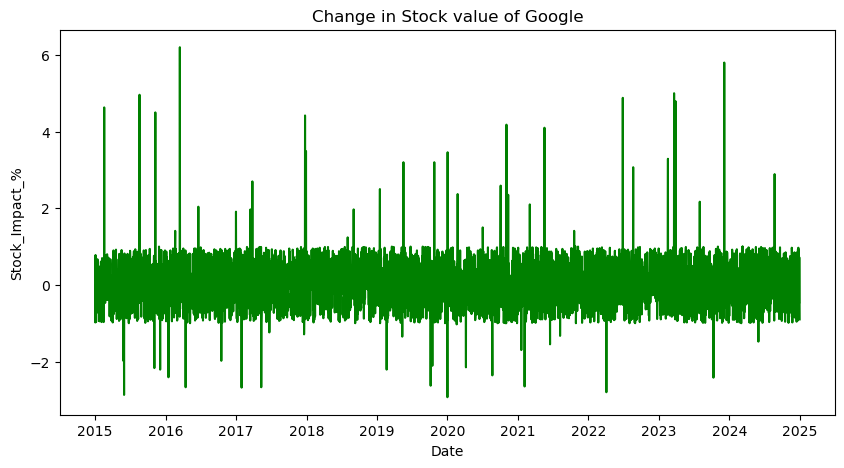

In [50]:
plt.figure(figsize = (10,5))

plt.plot( data_google['Date'], data_google['Stock_Impact_%'], color = 'green')
plt.title("Change in Stock value of Google")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")

plt.show()

In [46]:
data_meta = df [df['Company'] == 'Meta']
data_meta


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
7306,2015-01-01,Meta,50.39,18.95,-5.23,NaN,-0.42,2015,1
7307,2015-01-02,Meta,49.80,19.77,-1.16,NaN,0.63,2015,1
7308,2015-01-03,Meta,49.09,19.96,-0.21,NaN,0.73,2015,1
7309,2015-01-04,Meta,50.66,20.48,2.38,NaN,-0.26,2015,1
7310,2015-01-05,Meta,51.36,19.84,-0.80,NaN,-0.37,2015,1
...,...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024,12
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024,12
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024,12
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024,12


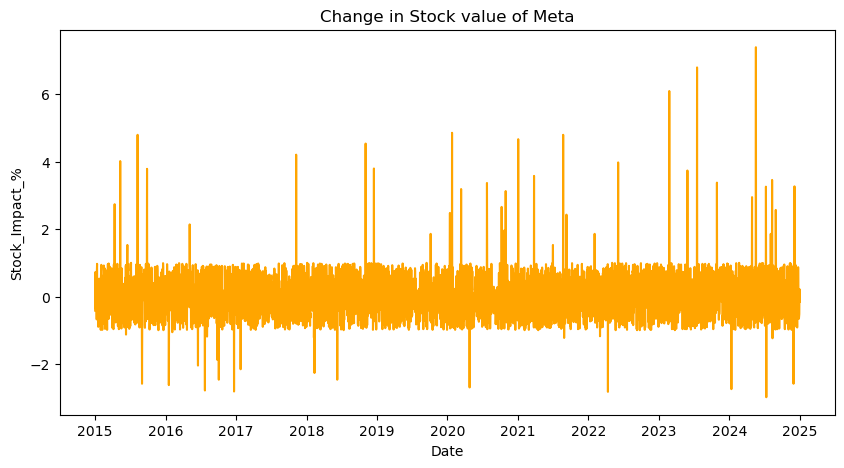

In [51]:
plt.figure(figsize = (10,5))

plt.plot( data_meta['Date'], data_meta['Stock_Impact_%'], color = "orange" )
plt.title("Change in Stock value of Meta")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")

plt.show()

#### Peak Market Volatility

##### Identification of specific dates or events that caused the highest stock impact

In [54]:
data_openAI.sort_values( by = 'Stock_Impact_%', ascending = False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
3408,2024-05-01,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.50,2024,5
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.20,2023,3
2890,2022-11-30,OpenAI,10.60,3.18,217.72,ChatGPT (GPT-3.5) launch,12.00,2022,11
2652,2022-04-06,OpenAI,9.24,3.48,247.93,DALL·E 2 release,9.80,2022,4
1988,2020-06-11,OpenAI,5.90,2.62,161.56,GPT-3 release,8.50,2020,6
...,...,...,...,...,...,...,...,...,...
3590,2024-10-30,OpenAI,11.05,5.27,427.50,AI-powered search update,-2.52,2024,10
1212,2018-04-27,OpenAI,5.38,1.76,76.47,AI ethics policy update,-2.70,2018,4
1303,2018-07-27,OpenAI,7.44,0.97,-2.63,AI-powered search update,-2.95,2018,7
2480,2021-10-16,OpenAI,8.39,2.78,178.28,AI Ads Optimization upgrade,-2.98,2021,10


In [55]:
data_google.sort_values( by = 'Stock_Impact_%', ascending = False )

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
4092,2016-03-15,Google,84.56,36.22,20.73,AlphaGo beats Lee Sedol,6.20,2016,3
6914,2023-12-06,Google,146.59,129.17,330.55,Gemini AI release,5.80,2023,12
6654,2023-03-21,Google,149.34,129.76,332.53,Bard chatbot launch,5.00,2023,3
3883,2015-08-19,Google,79.27,30.89,2.98,AI partnership deal,4.96,2015,8
6388,2022-06-28,Google,137.71,107.96,259.85,AI ethics policy update,4.88,2022,6
...,...,...,...,...,...,...,...,...,...
4122,2016-04-14,Google,87.19,36.08,20.28,AI partnership deal,-2.67,2016,4
4412,2017-01-29,Google,92.21,43.25,44.17,AI Ads Optimization upgrade,-2.68,2017,1
6303,2022-04-04,Google,138.00,106.81,256.04,AI Video Recommendation upgrade,-2.80,2022,4
3803,2015-05-31,Google,81.14,29.30,-2.32,Cloud AI launch,-2.87,2015,5


In [56]:
data_meta.sort_values(by = 'Stock_Impact_%', ascending = False )

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
10731,2024-05-18,Meta,103.64,103.05,415.23,LLaMA 3 release (predicted),7.40,2024,5
10426,2023-07-18,Meta,92.44,85.67,328.37,LLaMA 2 release,6.80,2023,7
10282,2023-02-24,Meta,93.71,86.98,334.89,LLaMA 1 release,6.10,2023,2
9156,2020-01-25,Meta,72.73,49.10,145.49,Cloud AI launch,4.86,2020,1
7526,2015-08-09,Meta,48.97,19.95,-0.27,AI Video Recommendation upgrade,4.80,2015,8
...,...,...,...,...,...,...,...,...,...
10604,2024-01-12,Meta,99.37,104.28,421.42,AI Video Recommendation upgrade,-2.75,2024,1
7875,2016-07-23,Meta,53.76,23.97,19.83,AI-powered search update,-2.79,2016,7
8026,2016-12-21,Meta,53.18,23.42,17.11,AI-powered search update,-2.82,2016,12
9964,2022-04-12,Meta,84.90,71.99,259.95,AI ethics policy update,-2.83,2022,4


#### Artificial Intelligence Revenue Trends

##### Yearly growth patterns in revenue specifically attributed to Artificial Intelligence

In [58]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1


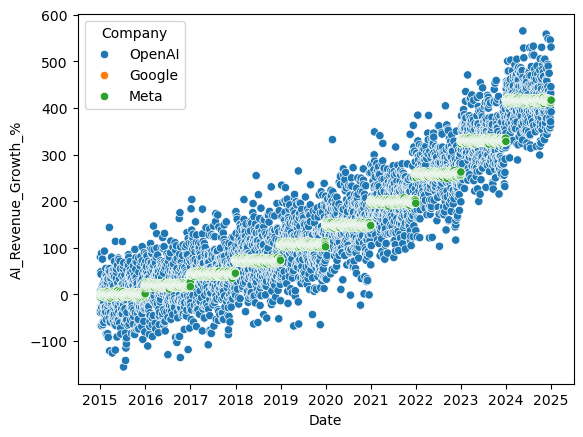

In [60]:
sns.scatterplot(x = 'Date', y = 'AI_Revenue_Growth_%', data = df, hue = 'Company')

plt.show()

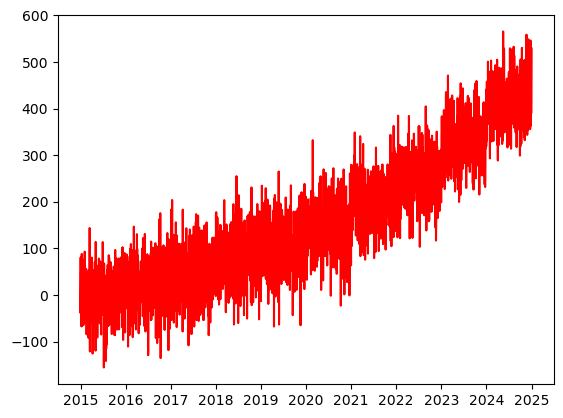

In [63]:
plt.plot( data_openAI['Date'], data_openAI['AI_Revenue_Growth_%'], color = 'red')

plt.show()

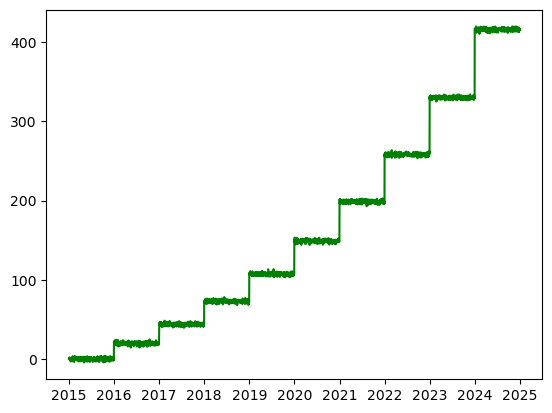

In [64]:
plt.plot( data_google['Date'], data_google['AI_Revenue_Growth_%'], color = 'green')

plt.show()

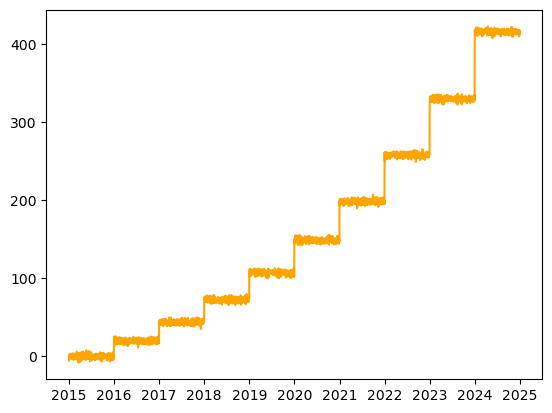

In [65]:
plt.plot( data_meta['Date'], data_meta['AI_Revenue_Growth_%'], color = 'orange')

plt.show()

#### Statistical Feature Correlation

###### An analysis of the mathematical relationships between all data variables

In [68]:
df.corr(numeric_only=True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year,Month
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.297701,-0.000023
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.526478,-0.000282
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.952199,-0.000093
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.016525,-0.000565
Year,0.297701,0.526478,0.952199,0.016525,1.000000,-0.000187
Month,-0.000023,-0.000282,-0.000093,-0.000565,-0.000187,1.000000


<Axes: >

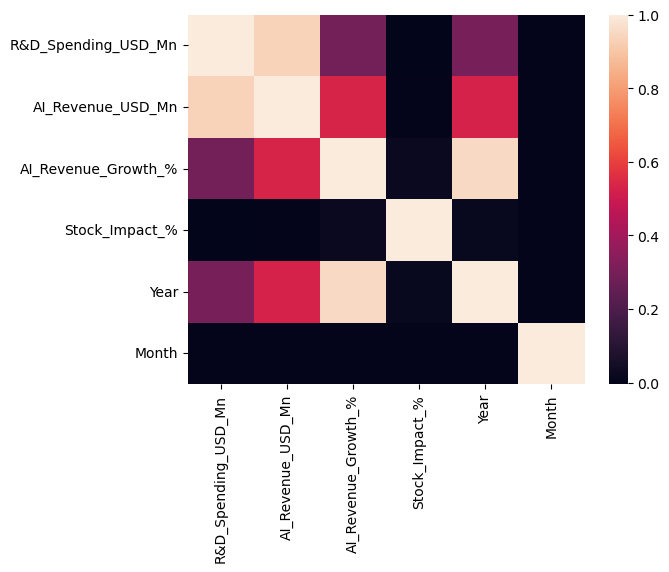

In [69]:
sns.heatmap( df.corr(numeric_only = True) )

#### Expenditure versus Revenue Analysis

###### A year-over-year comparison of spending against total earnings

In [71]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1


In [73]:
spend = df.groupby('Year')['R&D_Spending_USD_Mn'].sum()
spend

Year
2015    49304.23
2016    53349.94
2017    57475.12
2018    62002.16
2019    67071.51
2020    72602.53
2021    78207.32
2022    84390.17
2023    91193.92
2024    98760.08
Name: R&D_Spending_USD_Mn, dtype: float64

###### Showing the Amounnt spent on R & D

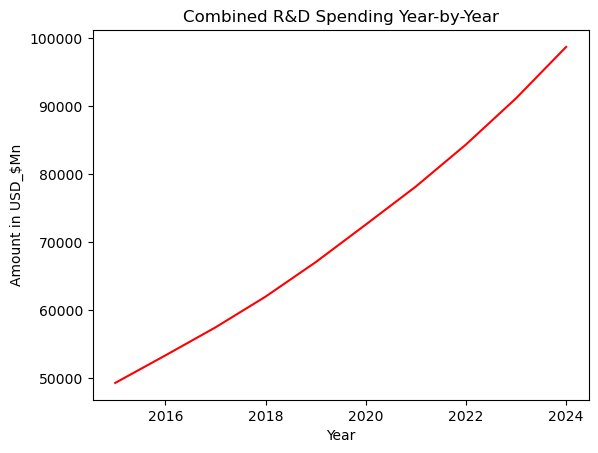

In [75]:
plt.plot(spend.index, spend.values, color = 'r')

plt.title("Combined R&D Spending Year-by-Year")
plt.xlabel("Year")
plt.ylabel("Amount in USD_$Mn")

plt.show()

In [76]:
revenue = df.groupby('Year')['AI_Revenue_USD_Mn'].sum()

revenue

Year
2015    18623.21
2016    22361.20
2017    26776.80
2018    32164.44
2019    38580.32
2020    46456.19
2021    55591.14
2022    66674.24
2023    80041.64
2024    96313.91
Name: AI_Revenue_USD_Mn, dtype: float64

###### Showing the Revenue earned

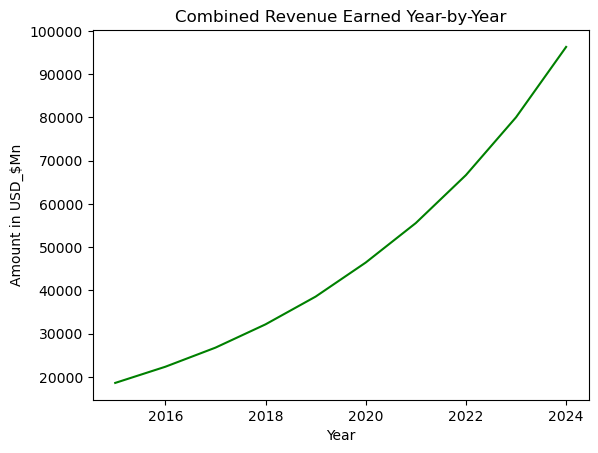

In [77]:
plt.plot( revenue.index, revenue.values, color = 'g')
plt.title( "Combined Revenue Earned Year-by-Year")
plt.xlabel("Year")
plt.ylabel("Amount in USD_$Mn")

plt.show()

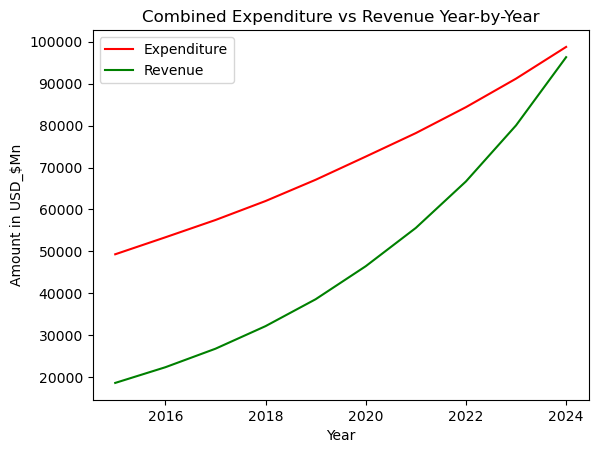

In [78]:
plt.plot(spend.index, spend.values, color = 'r')
plt.plot( revenue.index, revenue.values, color = 'g')

plt.title( "Combined Expenditure vs Revenue Year-by-Year", fontsize = 12)
plt.xlabel("Year")
plt.ylabel("Amount in USD_$Mn")

plt.legend(['Expenditure', 'Revenue'])

plt.show()

###### Pairplot to show the relations between the columns


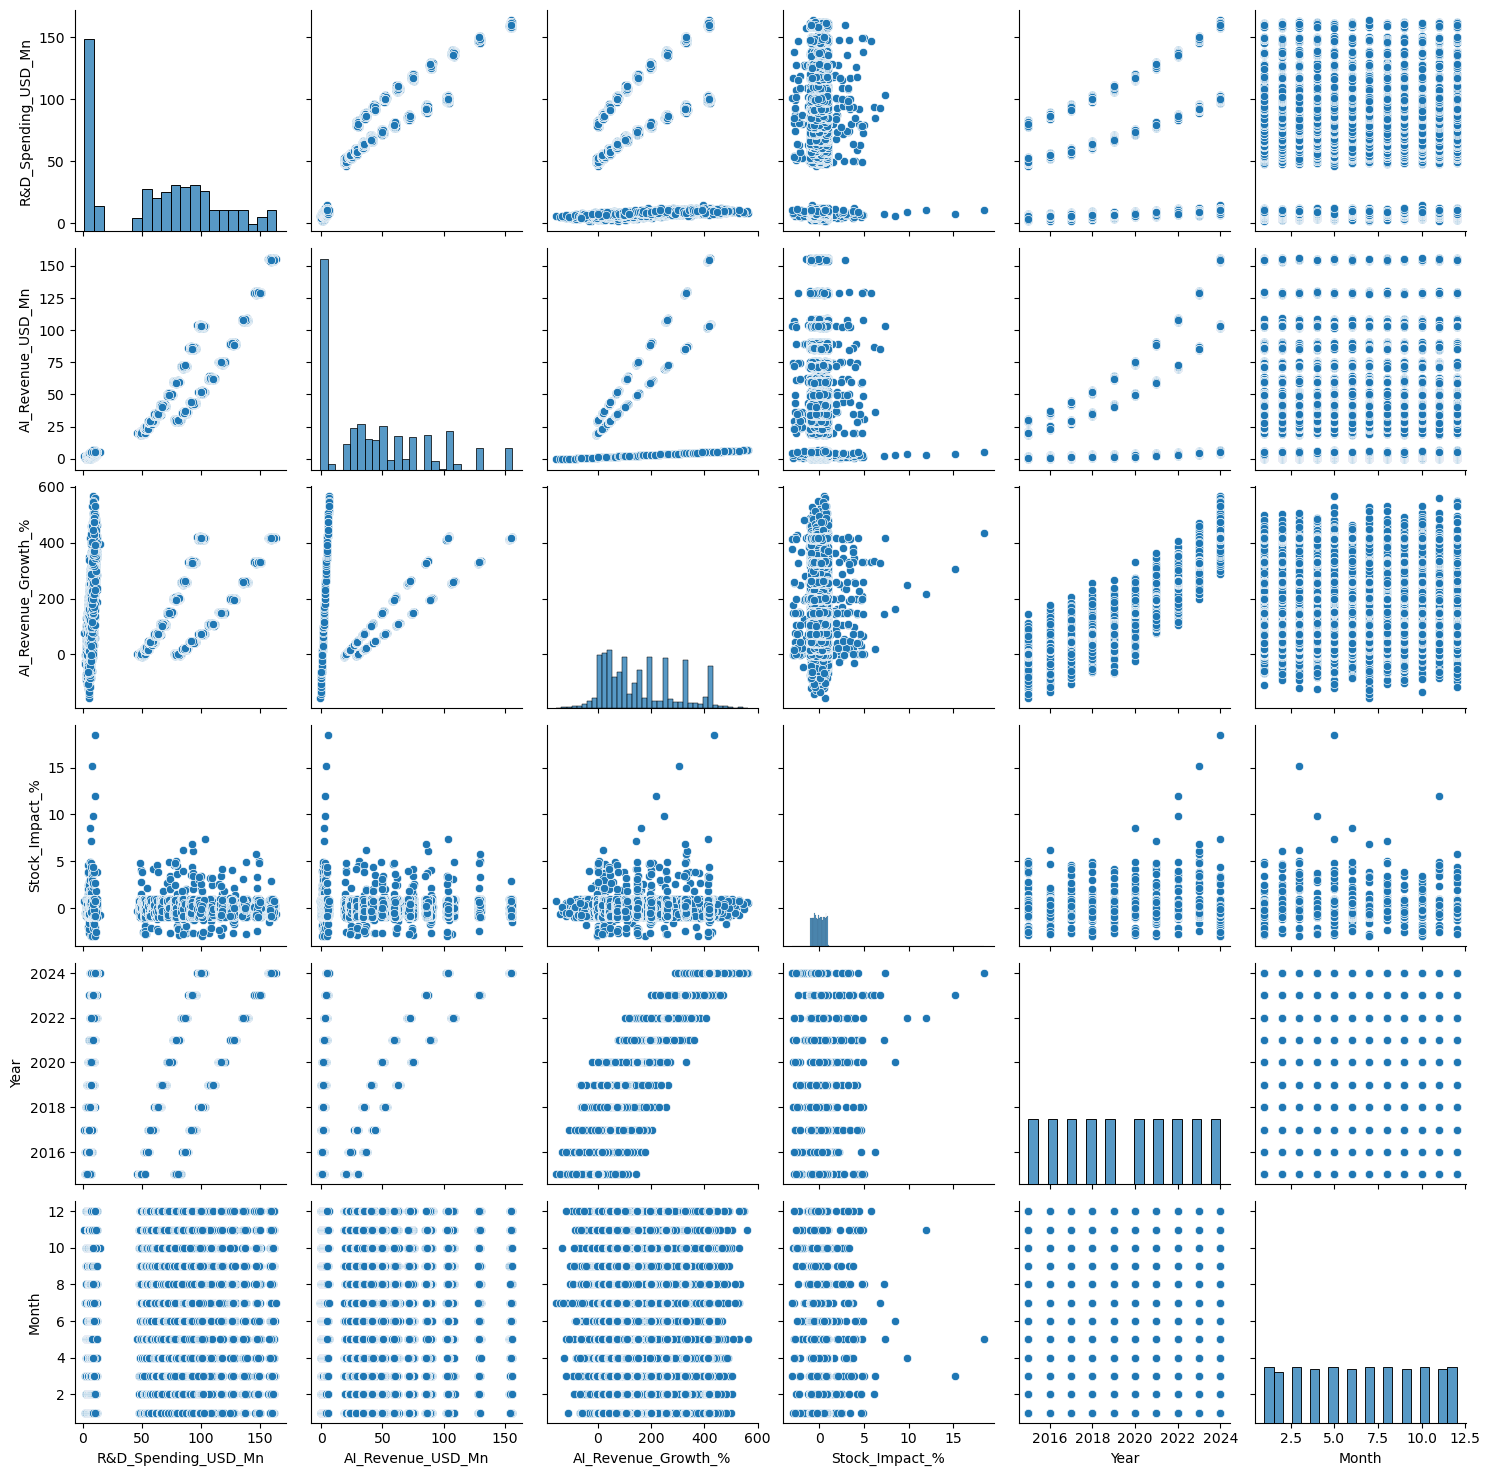

In [79]:
sns.pairplot(df);

#### Significant Event Impact

###### A detailed assessment of how specific milestones influenced market metrics

In [80]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1


###### Showing the various Events

In [81]:
df.Event.value_counts()

Event
AI speech recognition release      37
AI Ads Optimization upgrade        32
AI partnership deal                32
AI-powered search update           32
AI Video Recommendation upgrade    29
AI ethics policy update            27
Cloud AI launch                    27
GPT-1 release                       1
GPT-2 release                       1
GPT-3 release                       1
Codex release                       1
DALL·E 2 release                    1
ChatGPT (GPT-3.5) launch            1
GPT-4 release                       1
GPT-5 release (predicted)           1
TensorFlow open-source release      1
AlphaGo beats Lee Sedol             1
BERT for Search launch              1
MUM Search Model launch             1
Bard chatbot launch                 1
Gemini AI release                   1
LLaMA 1 release                     1
LLaMA 2 release                     1
LLaMA 3 release (predicted)         1
Name: count, dtype: int64

###### Checking for a particular event

In [82]:
df[ df.Event == 'TensorFlow open-source release' ]

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
3965,2015-11-09,Google,79.62,29.84,-0.53,TensorFlow open-source release,4.5,2015,11


In [83]:
tf = df.loc[ 3955 : 3975 ]

tf

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
3955,2015-10-30,Google,80.33,29.87,-0.43,NaN,0.43,2015,10
3956,2015-10-31,Google,79.53,30.30,0.99,NaN,-0.84,2015,10
3957,2015-11-01,Google,80.37,29.86,-0.48,NaN,0.57,2015,11
3958,2015-11-02,Google,77.89,29.97,-0.10,NaN,0.76,2015,11
3959,2015-11-03,Google,81.00,29.43,-1.89,NaN,-0.45,2015,11
3960,2015-11-04,Google,80.70,29.71,-0.96,AI speech recognition release,-2.17,2015,11
3961,2015-11-05,Google,78.31,30.25,0.85,NaN,0.31,2015,11
3962,2015-11-06,Google,79.08,29.84,-0.54,NaN,-0.72,2015,11
3963,2015-11-07,Google,79.65,30.34,1.14,NaN,0.58,2015,11
3964,2015-11-08,Google,79.63,29.74,-0.86,NaN,-0.61,2015,11


###### Showing the Impact with a line chart

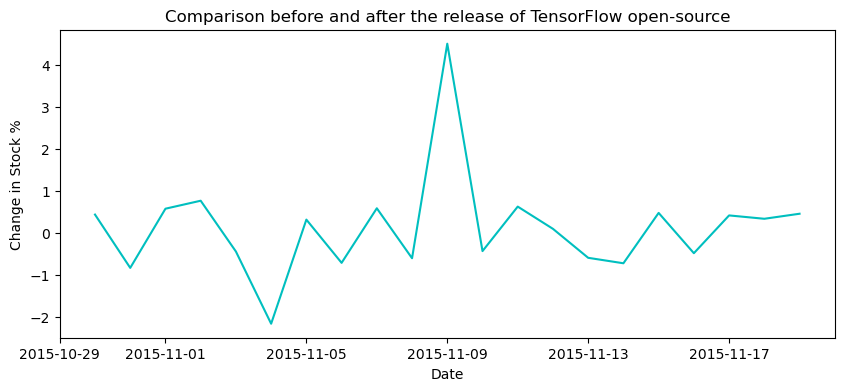

In [84]:
plt.figure(figsize = (10,4))

plt.plot( tf['Date'], tf['Stock_Impact_%'], color = 'c')
plt.title("Comparison before and after the release of TensorFlow open-source")
plt.xlabel("Date")
plt.ylabel("Change in Stock %")

plt.show()

###### Checking for a particular event

In [87]:
df[ df.Event == 'GPT-4 release' ]


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.2,2023,3


In [88]:
gpt4 = df.loc[ 2984 : 3004 ]

gpt4

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
2984,2023-03-04,OpenAI,10.59,4.26,326.43,NaN,-0.28,2023,3
2985,2023-03-05,OpenAI,8.24,3.58,257.92,NaN,-0.48,2023,3
2986,2023-03-06,OpenAI,9.32,4.21,320.60,NaN,0.89,2023,3
2987,2023-03-07,OpenAI,8.52,4.13,313.16,NaN,-0.08,2023,3
2988,2023-03-08,OpenAI,8.90,3.63,263.03,NaN,-0.56,2023,3
2989,2023-03-09,OpenAI,8.44,4.64,363.84,NaN,0.91,2023,3
2990,2023-03-10,OpenAI,9.55,4.83,383.49,NaN,-0.02,2023,3
2991,2023-03-11,OpenAI,8.34,3.95,294.67,NaN,0.19,2023,3
2992,2023-03-12,OpenAI,8.71,3.57,256.88,NaN,-0.87,2023,3
2993,2023-03-13,OpenAI,10.61,5.19,419.06,NaN,0.53,2023,3


###### Showing the Impact with a line chart

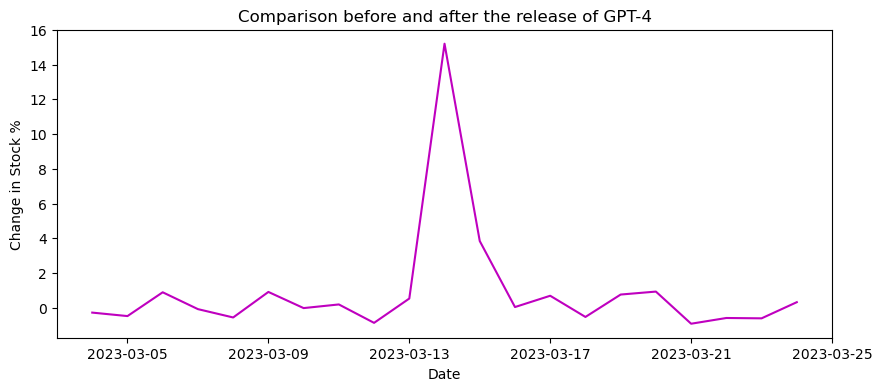

In [89]:
plt.figure(figsize = (10,4))

plt.plot( gpt4['Date'], gpt4['Stock_Impact_%'], color = 'm')

plt.title("Comparison before and after the release of GPT-4")
plt.xlabel("Date")
plt.ylabel("Change in Stock %")

plt.show()

In [90]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year,Month
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015,1
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015,1
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015,1
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015,1


###### Daily Average impact on the Stocks of the companies

In [91]:
df.groupby('Company')['Stock_Impact_%'].mean()*100

Company
Google    2.620860
Meta      0.976184
OpenAI    4.070901
Name: Stock_Impact_%, dtype: float64

###### Daily Average Expenditure on R & D by the companies

In [92]:
df.groupby('Company')['R&D_Spending_USD_Mn'].mean()

Company
Google    115.888623
Meta       72.415294
OpenAI      7.249595
Name: R&D_Spending_USD_Mn, dtype: float64

###### Maximum impact % on a company's stocks

In [93]:
df.groupby('Company')['Stock_Impact_%'].max()

Company
Google     6.2
Meta       7.4
OpenAI    18.5
Name: Stock_Impact_%, dtype: float64

#### Annual Index Variations

###### Fluctuations in the market index relative to each year and company

In [94]:
stocks = df.groupby(['Year', 'Company'])['Stock_Impact_%'].max()

stocks

Year  Company
2015  Google      4.96
      Meta        4.80
      OpenAI      3.92
2016  Google      6.20
      Meta        2.14
      OpenAI      4.66
2017  Google      4.42
      Meta        4.21
      OpenAI      4.63
2018  Google      1.97
      Meta        4.54
      OpenAI      4.94
2019  Google      3.20
      Meta        1.86
      OpenAI      4.20
2020  Google      4.18
      Meta        4.86
      OpenAI      8.50
2021  Google      4.10
      Meta        4.80
      OpenAI      7.20
2022  Google      4.88
      Meta        3.98
      OpenAI     12.00
2023  Google      5.80
      Meta        6.80
      OpenAI     15.20
2024  Google      2.89
      Meta        7.40
      OpenAI     18.50
Name: Stock_Impact_%, dtype: float64

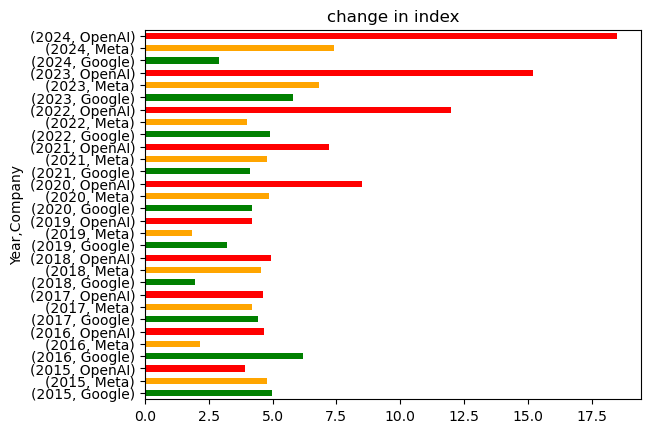

In [95]:
stocks.plot(kind = 'barh', color = ['green', 'orange', 'red'])

plt.title("change in index")

plt.show()